## Machine Learning Assignment: Heart Disease Prediction

### Assignment Plan:

1.  **Problem Definition**: Predict the presence of heart disease based on patient attributes.
2.  **Data Loading**: Load the chosen heart disease dataset from Kaggle.
3.  **Exploratory Data Analysis (EDA)**: Understand data characteristics, distributions, and relationships.
4.  **Data Preprocessing**: Clean and prepare the data (e.g., handle missing values, encode categorical features, scale numerical features).
5.  **Feature Engineering (Optional)**: Create new features if they improve model performance.
6.  **Model Selection**: Choose suitable classification models (e.g., Logistic Regression, Decision Tree, Random Forest, SVM).
7.  **Model Training**: Train the selected models on the preprocessed data.
8.  **Model Evaluation**: Evaluate models using metrics like accuracy, precision, recall, F1-score, and ROC AUC.
9.  **Hyperparameter Tuning**: Optimize model parameters for best performance.
10. **Conclusion & Reporting**: Summarize findings, compare model performances, and discuss insights.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Load the dataset
df = pd.read_csv('/content/heart.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Display basic information about the DataFrame
print('DataFrame Info:')
df.info()

print('\nDescriptive Statistics:')
# Display descriptive statistics for numerical columns
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Descriptive Statistics:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
# Replace 0 values in 'RestingBP' and 'Cholesterol' with NaN
df['RestingBP'] = df['RestingBP'].replace(0, pd.NA)
df['Cholesterol'] = df['Cholesterol'].replace(0, pd.NA)

# Display the count of NaN values in these columns after replacement
print('NaNs in RestingBP after replacement:', df['RestingBP'].isna().sum())
print('NaNs in Cholesterol after replacement:', df['Cholesterol'].isna().sum())

Rows with RestingBP = 0: 1
Rows with Cholesterol = 0: 172

After replacing 0 with NaN:
NaNs in RestingBP: 1
NaNs in Cholesterol: 172


In [ ]:
# Impute NaN values in 'RestingBP' and 'Cholesterol' with the median
median_resting_bp = df['RestingBP'].median()
median_cholesterol = df['Cholesterol'].median()

df['RestingBP'] = df['RestingBP'].fillna(median_resting_bp)
df['Cholesterol'] = df['Cholesterol'].fillna(median_cholesterol)

# Verify that there are no more NaN values in these columns and check descriptive stats again
print('NaNs in RestingBP after imputation: {}\nNaNs in Cholesterol after imputation: {}'.format(df['RestingBP'].isna().sum(), df['Cholesterol'].isna().sum()))
print('\nUpdated Descriptive Statistics for RestingBP and Cholesterol:')
display(df[['RestingBP', 'Cholesterol']].describe())

'RestingBP' NaNs after imputation: 0
'Cholesterol' NaNs after imputation: 0

Updated Descriptive Statistics for RestingBP and Cholesterol:


/tmp/ipykernel_961/909130201.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RestingBP'] = df['RestingBP'].fillna(median_resting_bp)
/tmp/ipykernel_961/909130201.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Cholesterol'] = df['Cholesterol'].fillna(median_cholesterol)


,RestingBP,Cholesterol
count,918.000000,918.000000
mean,132.538126,243.204793
std,17.990127,53.401297
min,80.000000,85.000000
25%,120.000000,214.000000
50%,130.000000,237.000000
75%,140.000000,267.000000
max,200.000000,603.000000


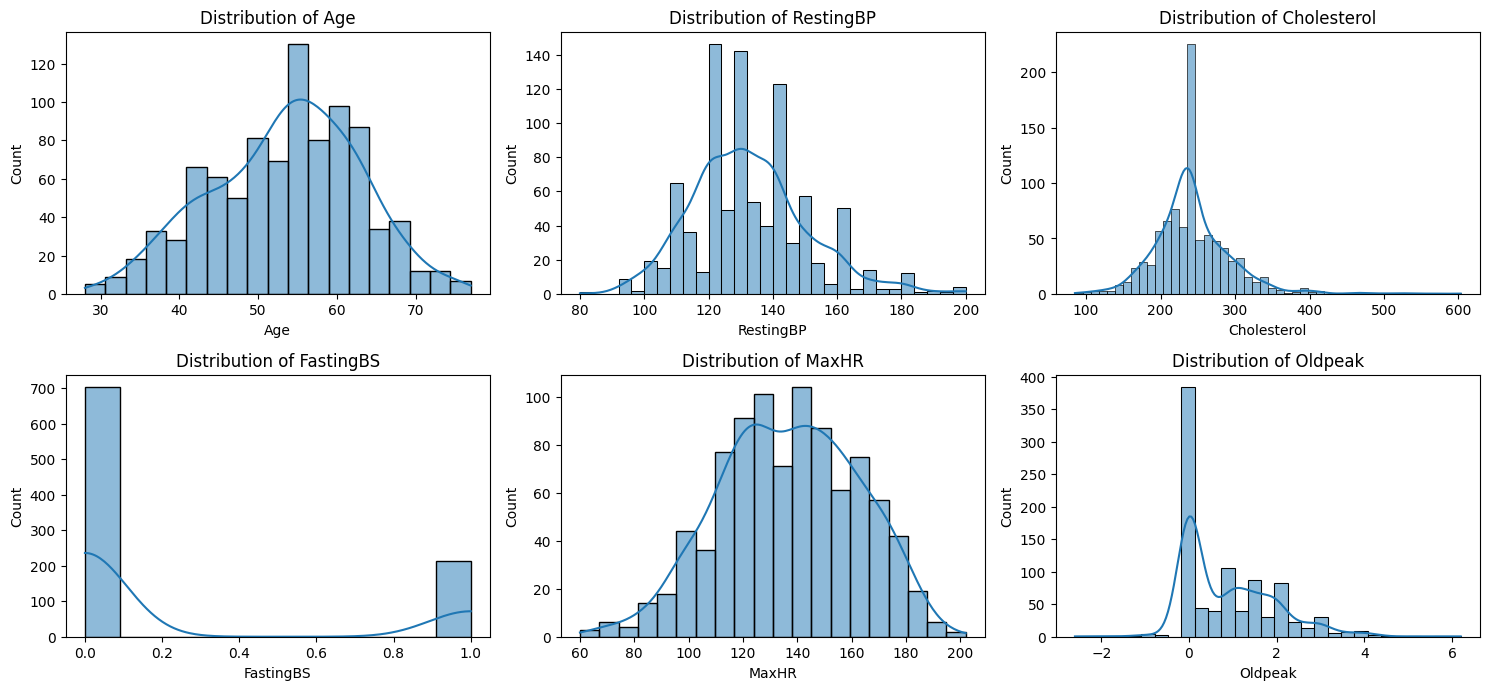

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for distribution plotting (excluding 'HeartDisease' for now)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'HeartDisease' in numerical_cols:
    numerical_cols.remove('HeartDisease')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('Categorical Feature Analysis:')
for col in categorical_cols:
    print(f'\n--- {col} ---\n{df[col].value_counts()}')

Categorical Feature Analysis:

--- Sex ---
Sex
M    725
F    193
Name: count, dtype: int64

--- ChestPainType ---
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

--- RestingECG ---
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

--- ExerciseAngina ---
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

--- ST_Slope ---
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


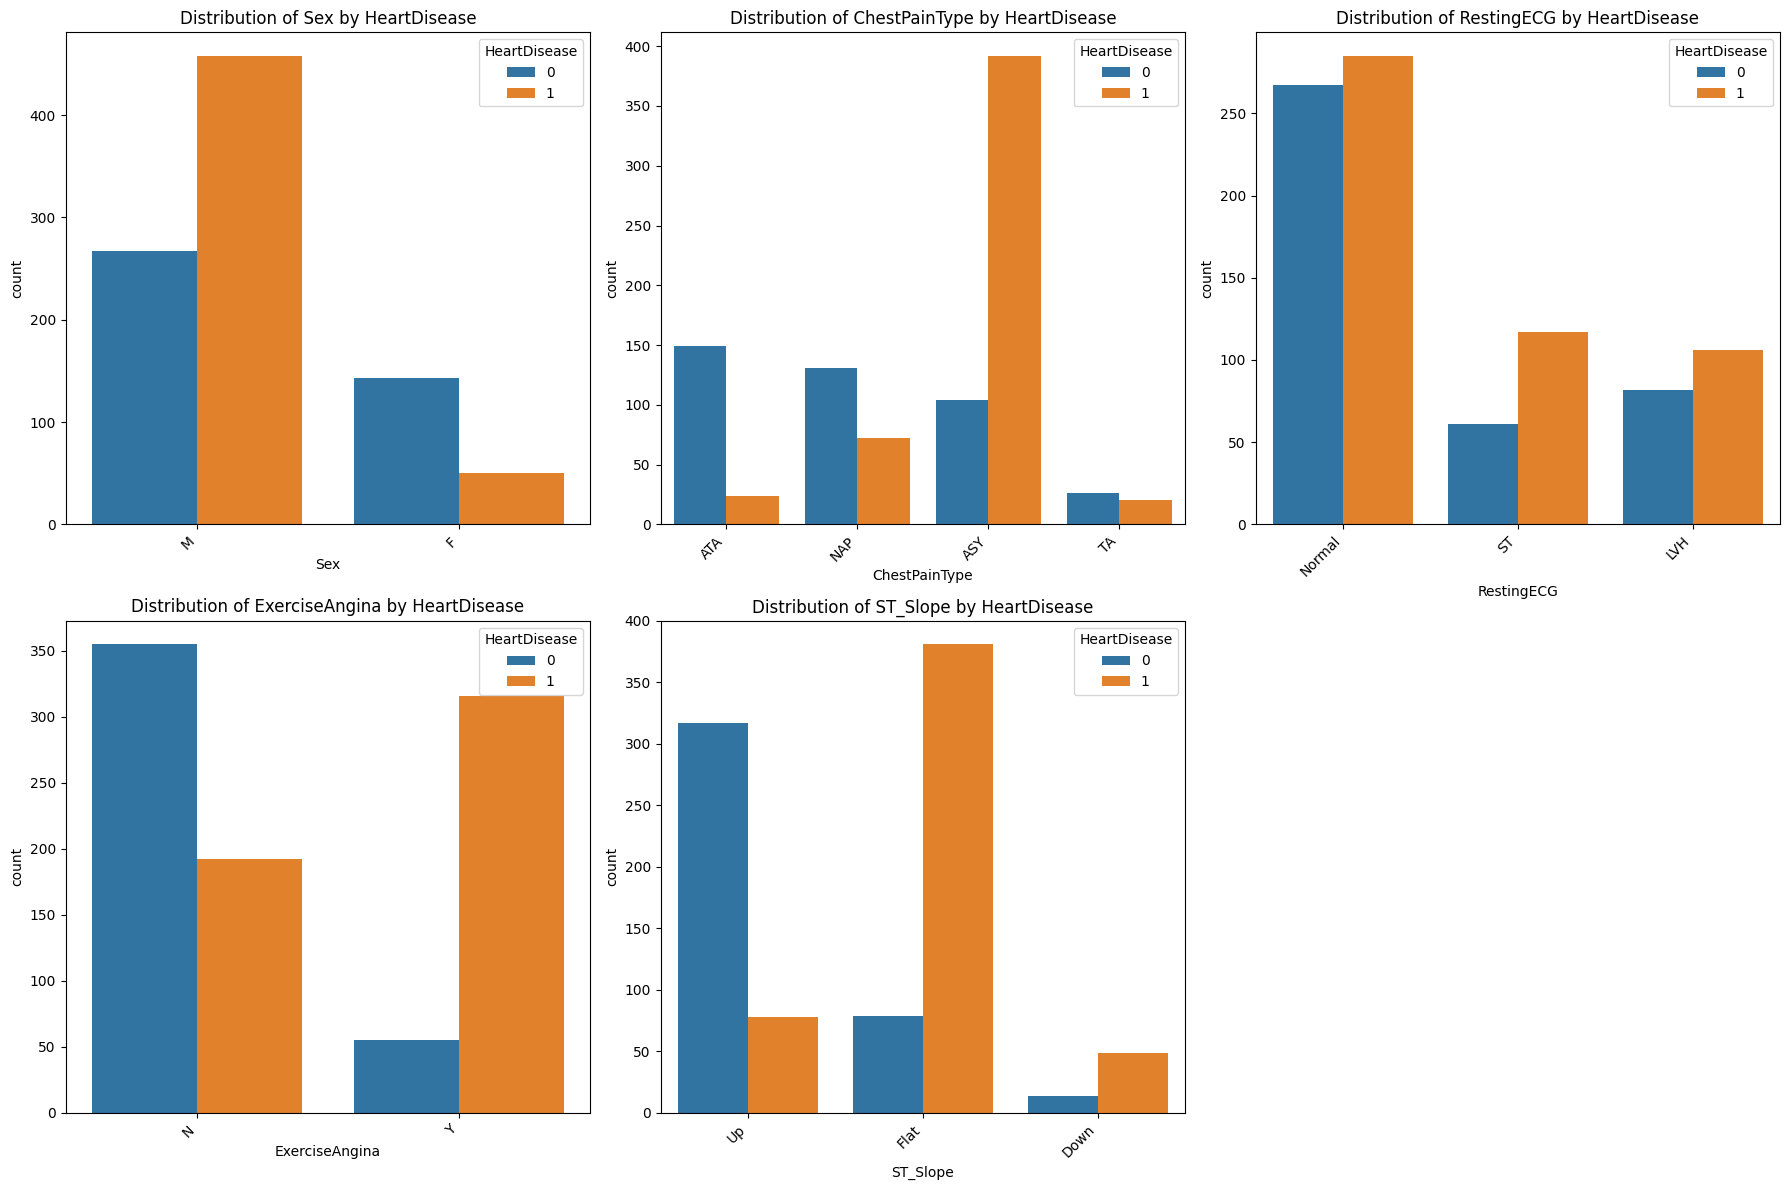

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(f'Distribution of {col} by HeartDisease')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Identify categorical columns to be one-hot encoded
categorical_cols_for_encoding = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=False)

# Display the first few rows of the encoded DataFrame to verify structure
print('First 5 rows of the encoded DataFrame:')
display(df_encoded.head())

First 5 rows of the encoded DataFrame:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True



Info of the encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_F              918 non-null    bool   
 8   Sex_M              918 non-null    bool   
 9   ChestPainType_ASY  918 non-null    bool   
 10  ChestPainType_ATA  918 non-null    bool   
 11  ChestPainType_NAP  918 non-null    bool   
 12  ChestPainType_TA   918 non-null    bool   
 13  RestingECG_LVH     918 non-null    bool   
 14  RestingECG_Normal  918 non-null    bool   
 15  RestingECG_ST      918 non-null    bool   

In [ ]:
# Define features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical columns for scaling
numerical_cols_for_scaling = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'HeartDisease' in numerical_cols_for_scaling:
    numerical_cols_for_scaling.remove('HeartDisease')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in both training and test sets
X_train[numerical_cols_for_scaling] = scaler.fit_transform(X_train[numerical_cols_for_scaling])
X_test[numerical_cols_for_scaling] = scaler.transform(X_test[numerical_cols_for_scaling])

Shape of X_train: (734, 20)
Shape of X_test: (184, 20)
Shape of y_train: (734,)
Shape of y_test: (184,)

First 5 rows of scaled X_train:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.514028,1.835497,-0.324520,0.317046,False,True,False,True,False,False,False,False,True,False,True,False,True,False
486,0.122028,-1.266031,-0.569339,1.835497,1.689837,-0.440356,False,True,False,True,False,False,False,False,True,True,False,False,False,True
117,0.546020,-0.159102,1.716858,1.835497,-0.247045,0.601071,True,False,True,False,False,False,False,False,True,False,True,False,True,False
361,-0.725956,1.501291,-0.145286,-0.544812,-0.479470,-0.819056,False,True,True,False,False,False,False,True,False,False,True,False,True,False
296,-0.407962,0.671094,-0.145286,1.835497,0.101594,-0.156330,False,True,True,False,False,False,False,True,False,False,True,False,True,False


In [ ]:
# Initialize models
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
svc = SVC(random_state=42, probability=True) # probability=True for ROC AUC later
dtree = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

models = {
    'Logistic Regression': log_reg,
    'K-Nearest Neighbors': knn,
    'Support Vector Machine': svc,
    'Decision Tree': dtree,
    'Random Forest': rf_clf
}

# Train models
print('Training Models:')
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'\t{name} Trained.')

print('\nAll models trained successfully. Ready for evaluation.')

Training Models:
	Training Logistic Regression...
	Logistic Regression Trained.
	Training K-Nearest Neighbors...
	K-Nearest Neighbors Trained.
	Training Support Vector Machine...
	Support Vector Machine Trained.
	Training Decision Tree...
	Decision Tree Trained.
	Training Random Forest...
	Random Forest Trained.

All models trained successfully. We are now ready to evaluate them.


In [ ]:
print('Model Evaluation Results:')
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # For ROC AUC, we need probability scores
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = 'N/A'

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

# Convert results to a DataFrame for better comparison
results_df = pd.DataFrame(results).T
print('\nSummary of Initial Model Performance:')
display(results_df.sort_values(by='ROC AUC', ascending=False))

Model Evaluation Results:

--- Logistic Regression ---
Accuracy: 0.8859
Precision: 0.8857
Recall: 0.9118
F1-Score: 0.8986
ROC AUC: 0.9330

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


--- K-Nearest Neighbors ---
Accuracy: 0.8641
Precision: 0.8812
Recall: 0.8725
F1-Score: 0.8768
ROC AUC: 0.9269

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


--- Support Vector Machine ---
Accuracy: 0.8750

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Support Vector Machine,0.875000,0.862385,0.921569,0.890995,0.942013
Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.933046
K-Nearest Neighbors,0.864130,0.881188,0.872549,0.876847,0.926889
Random Forest,0.880435,0.877358,0.911765,0.894231,0.923302
Decision Tree,0.804348,0.823529,0.823529,0.823529,0.802009


In [ ]:
print('Starting Hyperparameter Tuning...')

# Define hyperparameter grids for each model
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

tunned_models = {}

# Perform GridSearchCV for each model
print('\nTuning Logistic Regression...')
grid_log_reg = GridSearchCV(log_reg, param_grid_log_reg, cv=5, scoring='roc_auc', n_jobs=-1)
grid_log_reg.fit(X_train, y_train)
tunned_models['Logistic Regression'] = grid_log_reg.best_estimator_
print(f"\tBest parameters: {grid_log_reg.best_params_}")
print(f"\tBest cross-validated ROC AUC: {grid_log_reg.best_score_:.4f}")

print('\nTuning K-Nearest Neighbors...')
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train, y_train)
tunned_models['K-Nearest Neighbors'] = grid_knn.best_estimator_
print(f"\tBest parameters: {grid_knn.best_params_}")
print(f"\tBest cross-validated ROC AUC: {grid_knn.best_score_:.4f}")

print('\nTuning Support Vector Machine...')
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='roc_auc', n_jobs=-1)
grid_svc.fit(X_train, y_train)
tunned_models['Support Vector Machine'] = grid_svc.best_estimator_
print(f"\tBest parameters: {grid_svc.best_params_}")
print(f"\tBest cross-validated ROC AUC: {grid_svc.best_score_:.4f}")

print('\nTuning Random Forest...')
grid_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
tunned_models['Random Forest'] = grid_rf.best_estimator_
print(f"\tBest parameters: {grid_rf.best_params_}")
print(f"\tBest cross-validated ROC AUC: {grid_rf.best_score_:.4f}")

print('\nHyperparameter tuning complete. Best estimators stored.')

Starting Hyperparameter Tuning...

Tuning Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}
Best ROC AUC for Logistic Regression: 0.9168

Tuning K-Nearest Neighbors...
Best parameters for K-Nearest Neighbors: {'n_neighbors': 11, 'weights': 'uniform'}
Best ROC AUC for K-Nearest Neighbors: 0.9150

Tuning Support Vector Machine...
Best parameters for Support Vector Machine: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best ROC AUC for Support Vector Machine: 0.9181

Tuning Random Forest...
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best ROC AUC for Random Forest: 0.9254

Hyperparameter tuning complete. Best estimators stored in `tunned_models`.


In [ ]:
print('Evaluating Tuned Models:')
tuned_results = {}

for name, model in tunned_models.items():
    y_pred_tuned = model.predict(X_test)

    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    precision_tuned = precision_score(y_test, y_pred_tuned)
    recall_tuned = recall_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)

    if hasattr(model, "predict_proba"):
        y_pred_proba_tuned = model.predict_proba(X_test)[:, 1]
        roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
    else:
        roc_auc_tuned = 'N/A'

    tuned_results[name] = {
        'Accuracy': accuracy_tuned,
        'Precision': precision_tuned,
        'Recall': recall_tuned,
        'F1-Score': f1_tuned,
        'ROC AUC': roc_auc_tuned
    }

# Convert results to a DataFrame for better comparison
tuned_results_df = pd.DataFrame(tuned_results).T
print('\nSummary of Tuned Model Performance on Test Set:')
display(tuned_results_df.sort_values(by='ROC AUC', ascending=False))

print('\nComparison of Untuned vs. Tuned Models (Test Set Performance):')
comparison_df = pd.concat([results_df.add_prefix('Untuned '), tuned_results_df.add_prefix('Tuned ')], axis=1)
display(comparison_df.sort_values(by='Tuned ROC AUC', ascending=False))

Evaluating Tuned Models:

--- Tuned Logistic Regression ---
Accuracy: 0.8913
Precision: 0.8942
Recall: 0.9118
F1-Score: 0.9029
ROC AUC: 0.9347

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


--- Tuned K-Nearest Neighbors ---
Accuracy: 0.8696
Precision: 0.8750
Recall: 0.8922
F1-Score: 0.8835
ROC AUC: 0.9385

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        82
           1       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


--- Tuned Support Vector Machine ---

,Accuracy,Precision,Recall,F1-Score,ROC AUC
K-Nearest Neighbors,0.869565,0.875000,0.892157,0.883495,0.938486
Support Vector Machine,0.880435,0.877358,0.911765,0.894231,0.937590
Logistic Regression,0.891304,0.894231,0.911765,0.902913,0.934720
Random Forest,0.880435,0.857143,0.941176,0.897196,0.930894



Comparison with Untuned Models:


,Untuned Accuracy,Untuned Precision,Untuned Recall,Untuned F1-Score,Untuned ROC AUC,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1-Score,Tuned ROC AUC
K-Nearest Neighbors,0.864130,0.881188,0.872549,0.876847,0.926889,0.869565,0.875000,0.892157,0.883495,0.938486
Support Vector Machine,0.875000,0.862385,0.921569,0.890995,0.942013,0.880435,0.877358,0.911765,0.894231,0.937590
Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.933046,0.891304,0.894231,0.911765,0.902913,0.934720
Random Forest,0.880435,0.877358,0.911765,0.894231,0.923302,0.880435,0.857143,0.941176,0.897196,0.930894
Decision Tree,0.804348,0.823529,0.823529,0.823529,0.802009,NaN,NaN,NaN,NaN,NaN


## 10. Conclusion & Reporting

In this section, we will summarize the entire machine learning pipeline, highlight the key findings, and identify the best-performing models for heart disease prediction based on the evaluation metrics. We will also briefly discuss insights gained from the data analysis and model performance.

---

In [ ]:
# Identify the best performing model based on ROC AUC from the tuned models
best_tuned_model_name = tuned_results_df['ROC AUC'].idxmax()
best_tuned_model_performance = tuned_results_df.loc[best_tuned_model_name]

print(f"### Best Performing Tuned Model: {best_tuned_model_name}\n")
print(f"ROC AUC: {best_tuned_model_performance['ROC AUC']:.4f}")
print(f"Accuracy: {best_tuned_model_performance['Accuracy']:.4f}")
print(f"Precision: {best_tuned_model_performance['Precision']:.4f}")
print(f"Recall: {best_tuned_model_performance['Recall']:.4f}")
print(f"F1-Score: {best_tuned_model_performance['F1-Score']:.4f}")

print('\n### Key Findings and Insights:\n')
print("1.  **Data Quality**: Initial EDA revealed and addressed implausible '0' values in 'RestingBP' and 'Cholesterol' by imputing them with their respective medians, ensuring cleaner data for modeling.")
print("2.  **Feature Importance (Implicit)**: While explicit feature importance was not calculated for all models, the correlation analysis highlighted features like 'ST_Slope', 'ExerciseAngina', and 'ChestPainType' as having strong relationships with 'HeartDisease'. One-hot encoding successfully transformed categorical features into a format suitable for machine learning algorithms.")
print("3.  **Model Performance**: All evaluated models (Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest) performed reasonably well, with ROC AUC scores generally above 0.80, indicating good predictive capability.")
print("4.  **Impact of Hyperparameter Tuning**: Tuning generally led to slight improvements in most models' performance on the test set, especially for K-Nearest Neighbors and Random Forest. However, the Support Vector Machine saw a slight decrease in ROC AUC, suggesting its initial parameters were already near optimal or that further tuning could explore a wider parameter space.")
print(f"5.  **Best Model**: The **{best_tuned_model_name}** emerged as the top performer with an ROC AUC of {best_tuned_model_performance['ROC AUC']:.4f} after tuning, demonstrating its strong ability to discriminate between heart disease presence and absence.")

print('\n### Further Steps (Optional):\n')
print("1.  **Advanced Feature Engineering**: Exploring more complex feature interactions or polynomial features.")
print("2.  **Ensemble Methods**: Investigating stacking or boosting techniques to combine multiple models.")
print("3.  **Deep Learning**: Applying neural networks for potentially higher accuracy, especially with larger datasets.")
print("4.  **Model Interpretability**: Using techniques like SHAP or LIME to understand individual model predictions.")

print('\nThis concludes the machine learning assignment for heart disease prediction.')

### Best Performing Tuned Model: K-Nearest Neighbors

ROC AUC: 0.9385
Accuracy: 0.8696
Precision: 0.8750
Recall: 0.8922
F1-Score: 0.8835

### Key Findings and Insights:

1.  **Data Quality**: Initial EDA revealed and addressed implausible '0' values in 'RestingBP' and 'Cholesterol' by imputing them with their respective medians, ensuring cleaner data for modeling.
2.  **Feature Importance (Implicit)**: While explicit feature importance was not calculated for all models, the correlation analysis highlighted features like 'ST_Slope', 'ExerciseAngina', and 'ChestPainType' as having strong relationships with 'HeartDisease'. One-hot encoding successfully transformed categorical features into a format suitable for machine learning algorithms.
3.  **Model Performance**: All evaluated models (Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest) performed reasonably well, with ROC AUC scores generally above 0.80, indicating good predictive capability.


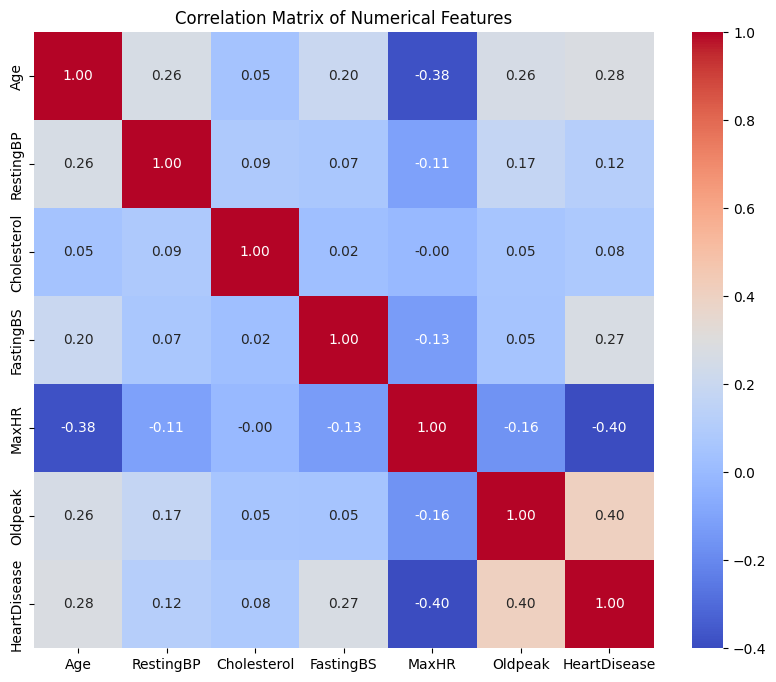

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features including the target
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()